In [3]:
#============================================================
# WEEK 1 — IoT Telemetry Ingestion & Signal Processing
# Project: Contextual Predictive Maintenance
# Intern Branch: preeti-dev
# ============================================================
 
# ── CELL 1: Import Libraries ──────────────────────────────


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore')
 
print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [18]:
# ── CELL 2: Load the Dataset ──────────────────────────────
df = pd.read_csv('../data/raw/ai4i2020.csv')

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [10]:
# ── CELL 3: Basic Dataset Info ────────────────────────────
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
df.info()
print("=== Column Names ===")
print(df.columns.tolist())
 
print("\n=== Data Types ===")
print(df.dtypes)
 
print("\n=== Missing Values ===")
print(df.isnull().sum())

Rows: 10000
Columns: 14
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtyp

In [9]:
# ── CELL 4: Check Target Variable (Machine Failure) ───────
print("=== Machine Failure Distribution ===")
print(df['Machine failure'].value_counts())
print()
 
failure_rate = df['Machine failure'].sum() / len(df) * 100
print(f"Failure Rate: {failure_rate:.2f}%")
print(f"No Failure: {(df['Machine failure'] == 0).sum()} records")
print(f"Failure:    {(df['Machine failure'] == 1).sum()} records")
 

=== Machine Failure Distribution ===
Machine failure
0    9661
1     339
Name: count, dtype: int64

Failure Rate: 3.39%
No Failure: 9661 records
Failure:    339 records


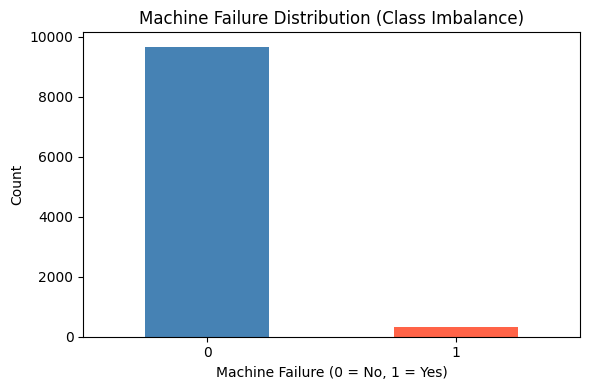

✅ Plot saved to reports/class_imbalance.png


In [19]:
# ── CELL 5: Visualize Class Imbalance ────────────────────
plt.figure(figsize=(6, 4))
df['Machine failure'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Machine Failure Distribution (Class Imbalance)')
plt.xlabel('Machine Failure (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../reports/class_imbalance.png', dpi=150)
plt.show()
print("✅ Plot saved to reports/class_imbalance.png")

In [12]:
# ── CELL 6: Select Sensor Columns ─────────────────────────
# These are the internal IoT sensor signals we care about
sensor_cols = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]
 
print("=== Sensor Column Statistics ===")
print(df[sensor_cols].describe().round(2))

=== Sensor Column Statistics ===
       Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
count              10000.0                 10000.00                10000.00   
mean                 300.0                   310.01                 1538.78   
std                    2.0                     1.48                  179.28   
min                  295.3                   305.70                 1168.00   
25%                  298.3                   308.80                 1423.00   
50%                  300.1                   310.10                 1503.00   
75%                  301.5                   311.10                 1612.00   
max                  304.5                   313.80                 2886.00   

       Torque [Nm]  Tool wear [min]  
count     10000.00         10000.00  
mean         39.99           107.95  
std           9.97            63.65  
min           3.80             0.00  
25%          33.20            53.00  
50%          40.10         

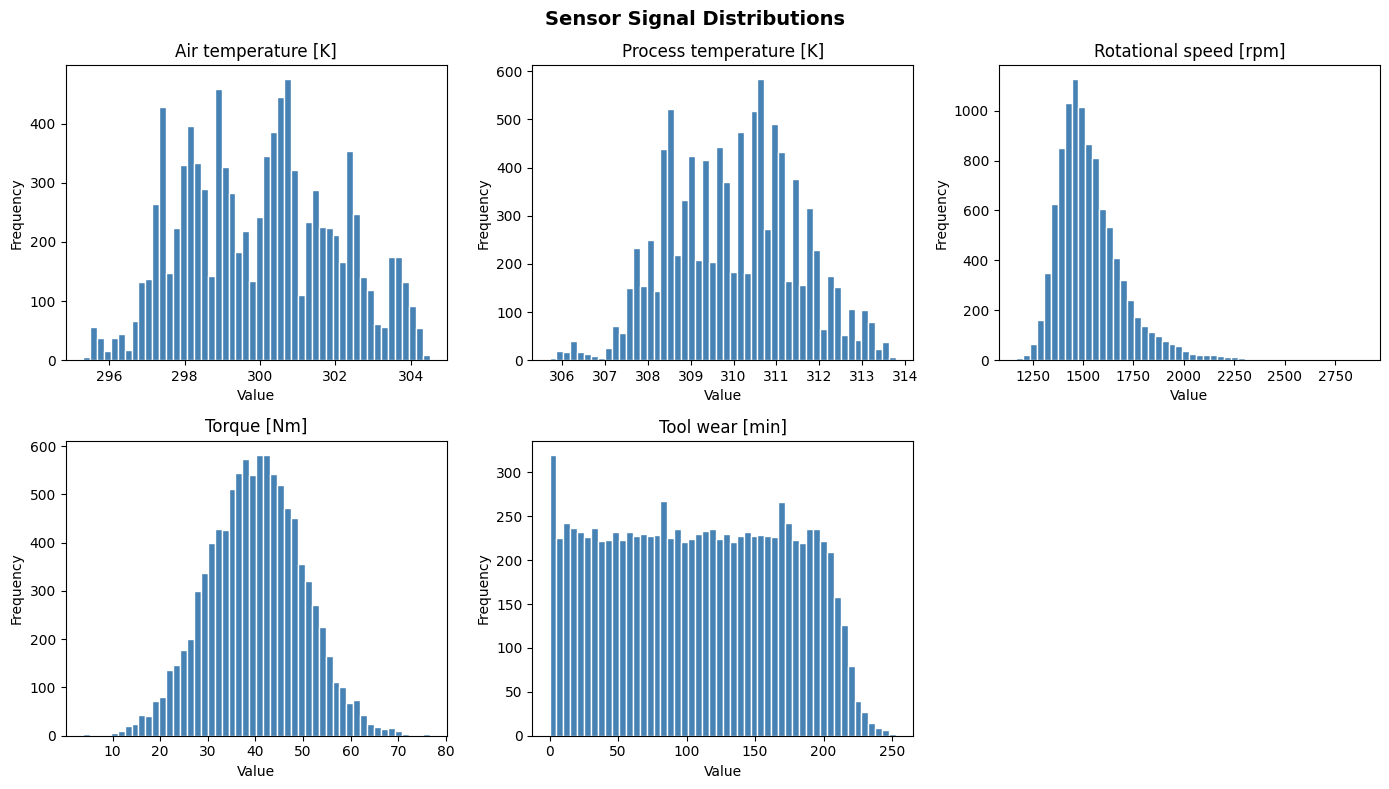

✅ Plot saved to reports/sensor_distributions.png


In [20]:
# ── CELL 7: Visualize Sensor Distributions ────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
 
for i, col in enumerate(sensor_cols):
    axes[i].hist(df[col], bins=50, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
 
# Hide the extra subplot
axes[5].set_visible(False)
 
plt.suptitle('Sensor Signal Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/sensor_distributions.png', dpi=150)
plt.show()
print("✅ Plot saved to reports/sensor_distributions.png")

In [14]:
# ── CELL 8: Compute Rolling Features ──────────────────────
# Rolling window = 10 rows (simulating a time window of 10 readings)
# This is the key Week 1 task — extracting signal patterns over time
 
WINDOW = 10
 
print(f"Computing rolling features with window size = {WINDOW}...")
 
for col in sensor_cols:
    col_clean = col.replace(' ', '_').replace('[', '').replace(']', '')
 
    # Rolling Mean — average value in the window
    df[f'{col_clean}_roll_mean'] = df[col].rolling(window=WINDOW, min_periods=1).mean()
 
    # Rolling Std — how much the signal is fluctuating
    df[f'{col_clean}_roll_std'] = df[col].rolling(window=WINDOW, min_periods=1).std().fillna(0)
 
    # Rolling Variance — another measure of signal variability
    df[f'{col_clean}_roll_var'] = df[col].rolling(window=WINDOW, min_periods=1).var().fillna(0)
 
print(f"\n✅ Rolling features created!")
print(f"New dataset shape: {df.shape}")
print(f"\nNew columns added:")
new_cols = [c for c in df.columns if 'roll' in c]
for c in new_cols:
    print(f"   {c}")

Computing rolling features with window size = 10...

✅ Rolling features created!
New dataset shape: (10000, 29)

New columns added:
   Air_temperature_K_roll_mean
   Air_temperature_K_roll_std
   Air_temperature_K_roll_var
   Process_temperature_K_roll_mean
   Process_temperature_K_roll_std
   Process_temperature_K_roll_var
   Rotational_speed_rpm_roll_mean
   Rotational_speed_rpm_roll_std
   Rotational_speed_rpm_roll_var
   Torque_Nm_roll_mean
   Torque_Nm_roll_std
   Torque_Nm_roll_var
   Tool_wear_min_roll_mean
   Tool_wear_min_roll_std
   Tool_wear_min_roll_var


In [22]:
# ── CELL 8b: Verify Rolling Features Exist ──────────────
# Safety check: ensure rolling features were created before visualization

# Check if rolling features exist
rolling_cols_exist = any('roll_mean' in col for col in df.columns)

if not rolling_cols_exist:
    print("⚠️  Rolling features not found. Creating them now...")
    
    WINDOW = 10
    sensor_cols = [
        'Air temperature [K]',
        'Process temperature [K]',
        'Rotational speed [rpm]',
        'Torque [Nm]',
        'Tool wear [min]'
    ]
    
    for col in sensor_cols:
        col_clean = col.replace(' ', '_').replace('[', '').replace(']', '')
        df[f'{col_clean}_roll_mean'] = df[col].rolling(window=WINDOW, min_periods=1).mean()
        df[f'{col_clean}_roll_std'] = df[col].rolling(window=WINDOW, min_periods=1).std().fillna(0)
        df[f'{col_clean}_roll_var'] = df[col].rolling(window=WINDOW, min_periods=1).var().fillna(0)
    
    print("✅ Rolling features created successfully!")
else:
    print("✅ Rolling features already exist. Proceeding with visualization...")

# Verify the specific column we need
print(f"\n✓ Column 'Air_temperature_K_roll_mean' exists: {'Air_temperature_K_roll_mean' in df.columns}")


⚠️  Rolling features not found. Creating them now...
✅ Rolling features created successfully!

✓ Column 'Air_temperature_K_roll_mean' exists: True


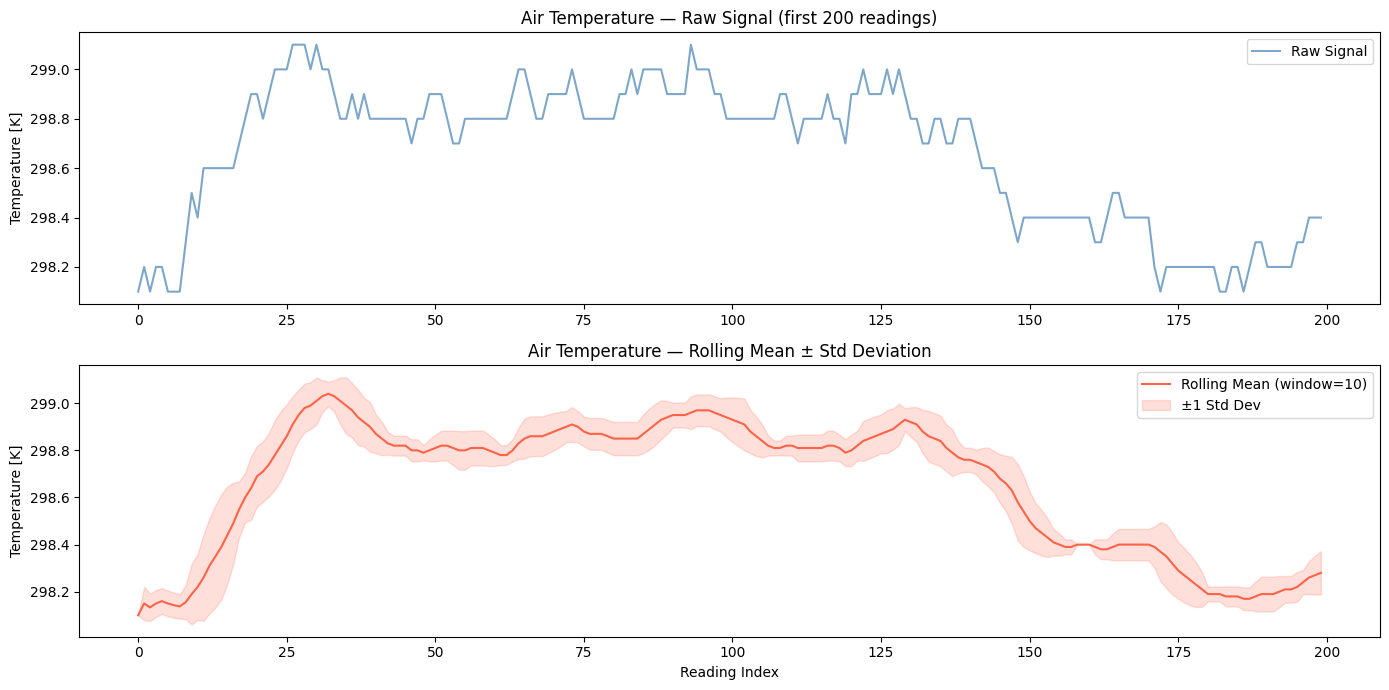

✅ Plot saved to reports/rolling_features_viz.png


In [23]:
# ── CELL 9: Visualize Rolling Mean vs Raw Signal ──────────
fig, axes = plt.subplots(2, 1, figsize=(14, 7))
 
# Plot raw signal
axes[0].plot(df['Air temperature [K]'][:200], color='steelblue', alpha=0.7, label='Raw Signal')
axes[0].set_title('Air Temperature — Raw Signal (first 200 readings)')
axes[0].set_ylabel('Temperature [K]')
axes[0].legend()
 
# Plot rolling mean
axes[1].plot(df['Air_temperature_K_roll_mean'][:200], color='tomato', label='Rolling Mean (window=10)')
axes[1].fill_between(
    range(200),
    (df['Air_temperature_K_roll_mean'][:200] - df['Air_temperature_K_roll_std'][:200]),
    (df['Air_temperature_K_roll_mean'][:200] + df['Air_temperature_K_roll_std'][:200]),
    alpha=0.2, color='tomato', label='±1 Std Dev'
)
axes[1].set_title('Air Temperature — Rolling Mean ± Std Deviation')
axes[1].set_ylabel('Temperature [K]')
axes[1].set_xlabel('Reading Index')
axes[1].legend()
 
plt.tight_layout()
plt.savefig('../reports/rolling_features_viz.png', dpi=150)
plt.show()
print("✅ Plot saved to reports/rolling_features_viz.png")

In [16]:
# ── CELL 11: Save Processed Data ──────────────────────────
df.to_csv('data/processed/week1_features.csv', index=False)
 
print("✅ Processed dataset saved to data/processed/week1_features.csv")
print(f"\nFinal dataset shape: {df.shape}")
print("\n=== Week 1 Summary ===")
print(f"  Total records        : {len(df)}")
print(f"  Failure records      : {df['Machine failure'].sum()}")
print(f"  Failure rate         : {df['Machine failure'].mean()*100:.2f}%")
print(f"  Rolling features     : {len(new_cols)} new columns created")
print(f"  Sensor columns used  : {len(sensor_cols)}")
print("\n✅ Week 1 — Data Ingestion & Signal Processing COMPLETE")

OSError: Cannot save file into a non-existent directory: 'data\processed'